# CIFAR-10 Image Classification — ResNet CNN

**Goal:** Build a high-accuracy CNN for CIFAR-10 classification.

**Key ideas:**

- Custom ResNet architecture with residual connections (2 blocks per layer)
- Strong data augmentation (crop + flip + color jitter + rotation + random erasing)
- Mixup augmentation (α=0.4) for improved generalization
- Normalize using dataset statistics (mean, std)
- Train with SGD + Nesterov momentum + OneCycleLR scheduler
- Label smoothing (0.1) to prevent overconfident predictions
- Support multi-GPU training with `DataParallel`
- Strong test-time augmentation (10 passes, averaged probabilities)

**Final test accuracy: 0.93**

---

# Imports

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
sns.set_style("whitegrid")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("GPUs:", torch.cuda.device_count())

Device: cuda
GPUs: 2


## Load Data

In [2]:
train_data = torch.load("/kaggle/input/competitions/sjtu-2026-spring-cnn/training.pt", weights_only=False)
test_data = torch.load("/kaggle/input/competitions/sjtu-2026-spring-cnn/test-shuffled-nolabel.pt", weights_only=False)

X, y = train_data
X_test = test_data
y = np.array(y)
print("Train:", X.shape, y.shape)
print("Test:", X_test.shape)

X_norm = X / 255.0
mean = X_norm.mean(axis=(0, 1, 2))
std = X_norm.std(axis=(0, 1, 2))
print("Mean:", mean, "Std:", std)

Train: (50000, 32, 32, 3) (50000,)
Test: (10000, 32, 32, 3)
Mean: [0.49139968 0.48215841 0.44653091] Std: [0.24703223 0.24348513 0.26158784]


# # Visualize Sample Images

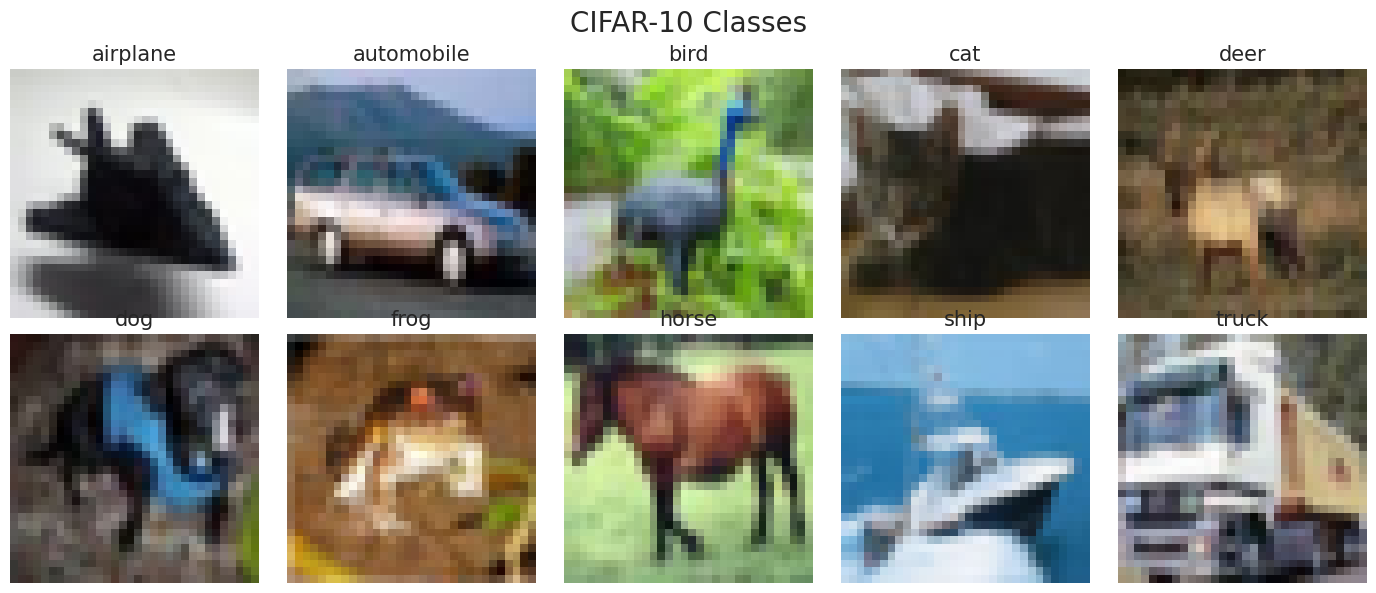

In [3]:
class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    idx = np.where(y == i)[0][0]
    ax.imshow(X[idx])
    ax.set_title(class_names[i], fontsize=15)
    ax.axis('off')
plt.suptitle("CIFAR-10 Classes", fontsize=20)
plt.tight_layout()
plt.show()

## CIFARDataset

In [4]:
class CIFARDataset(Dataset):
    def __init__(self, images, labels=None, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]

        if isinstance(img, torch.Tensor):
            img = img.numpy()

        if self.transform:
            img = self.transform(img)

        if self.labels is not None:
            return img, int(self.labels[idx])
        return img

## Transforms

In [5]:
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.3, 0.3, 0.3, 0.1),
    transforms.RandomRotation(15),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean.tolist(), std.tolist()),
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.2)),
])
val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(mean.tolist(), std.tolist()),
])

## Train/Val Split

In [6]:
dataset = CIFARDataset(X, y, transform=train_transform)

train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
val_dataset.dataset.transform = val_transform

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=2)

## CNN Model

In [7]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )
    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return self.relu(out)

class ResNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.prep = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )
        self.layer1 = ResidualBlock(64, 128)
        self.pool1 = nn.MaxPool2d(2)
        self.layer2 = ResidualBlock(128, 256)
        self.pool2 = nn.MaxPool2d(2)
        self.layer3 = ResidualBlock(256, 512)
        self.pool3 = nn.MaxPool2d(2)
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(512, 10)
        )
    def forward(self, x):
        x = self.prep(x)
        x = self.pool1(self.layer1(x))
        x = self.pool2(self.layer2(x))
        x = self.pool3(self.layer3(x))
        return self.classifier(x)

model = ResNet()
if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)
model = model.to(device)
print("Parameters:", sum(p.numel() for p in model.parameters()))

Parameters: 4829258


## Training Setup

In [8]:
EPOCHS = 100
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4, nesterov=True)
scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=0.1, epochs=EPOCHS, steps_per_epoch=len(train_loader))

def train_one_epoch():
    model.train()
    correct, total_loss = 0, 0
    for images, labels in tqdm(train_loader):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        scheduler.step()
        total_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
    return total_loss / len(train_dataset), correct / len(train_dataset)

def validate():
    model.eval()
    correct, total_loss = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
    return total_loss / len(val_dataset), correct / len(val_dataset)

## Model Training

In [9]:
best_acc = 0
train_losses, val_losses, train_accs, val_accs = [], [], [], []

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch()
    val_loss, val_acc = validate()
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")

print("Best Val Acc:", best_acc)

100%|██████████| 352/352 [00:22<00:00, 15.43it/s]


Epoch 1/100 | Train Acc: 0.5091 | Val Acc: 0.6532


100%|██████████| 352/352 [00:20<00:00, 17.15it/s]


Epoch 2/100 | Train Acc: 0.6580 | Val Acc: 0.6946


100%|██████████| 352/352 [00:20<00:00, 17.00it/s]


...

Epoch 98/100 | Train Acc: 1.0000 | Val Acc: 0.9064


100%|██████████| 352/352 [00:22<00:00, 15.85it/s]


Epoch 99/100 | Train Acc: 1.0000 | Val Acc: 0.9058


100%|██████████| 352/352 [00:21<00:00, 16.06it/s]


Epoch 100/100 | Train Acc: 1.0000 | Val Acc: 0.9072
Best Val Acc: 0.9086


## Training Summary

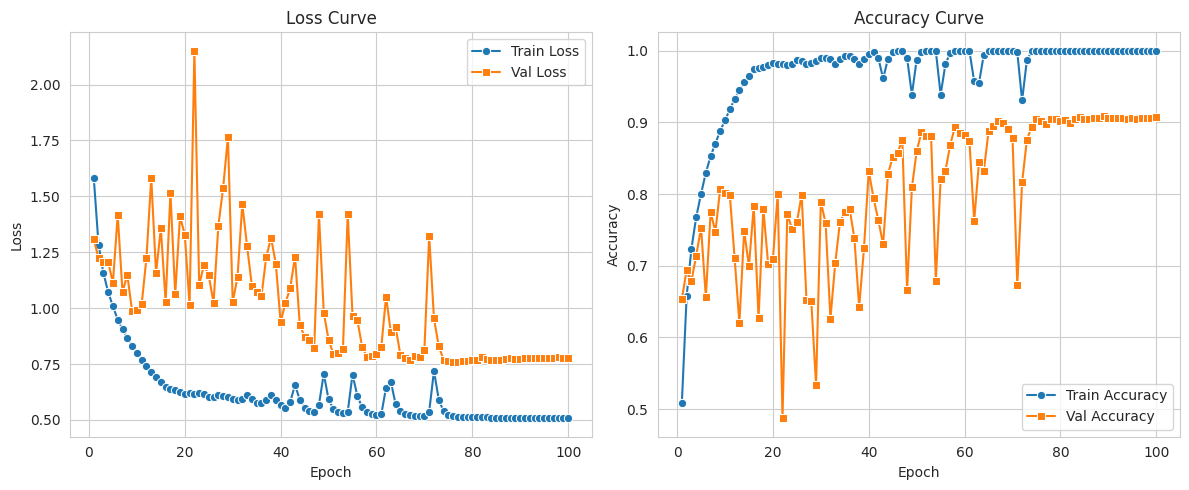

In [10]:
epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
sns.lineplot(x=epochs, y=train_losses, marker="o", label="Train Loss")
sns.lineplot(x=epochs, y=val_losses, marker="s", label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")

# Accuracy
plt.subplot(1, 2, 2)
sns.lineplot(x=epochs, y=train_accs, marker="o", label="Train Accuracy")
sns.lineplot(x=epochs, y=val_accs, marker="s", label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")

plt.tight_layout()
plt.show()

## Confusion Matrix

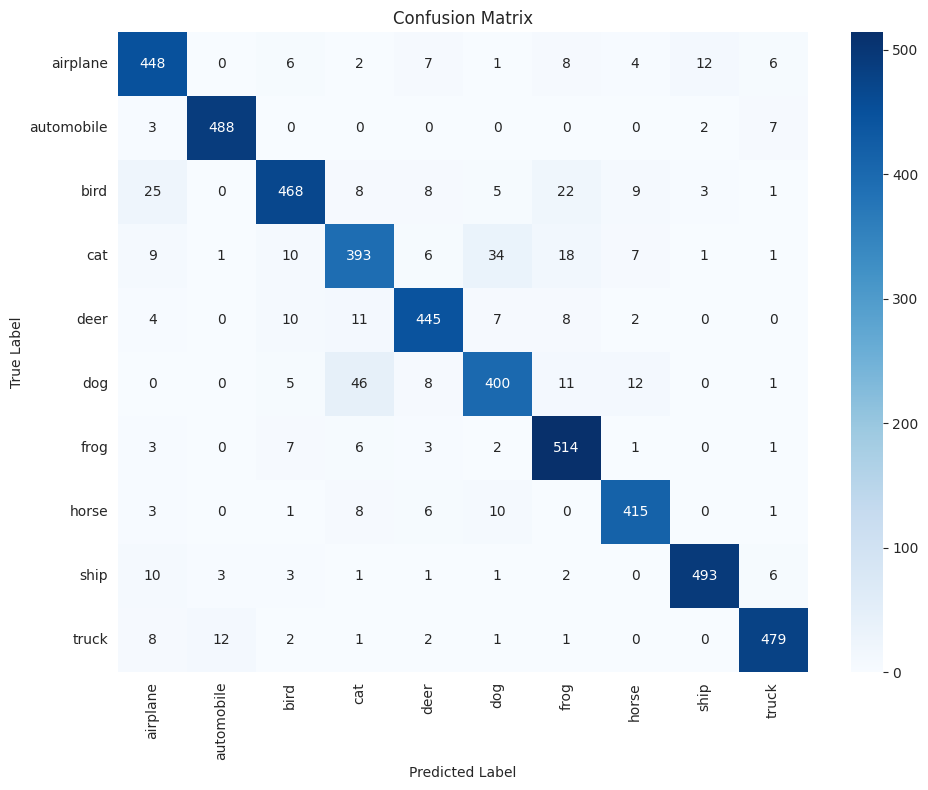

              precision    recall  f1-score   support

    airplane       0.87      0.91      0.89       494
  automobile       0.97      0.98      0.97       500
        bird       0.91      0.85      0.88       549
         cat       0.83      0.82      0.82       480
        deer       0.92      0.91      0.91       487
         dog       0.87      0.83      0.85       483
        frog       0.88      0.96      0.92       537
       horse       0.92      0.93      0.93       444
        ship       0.96      0.95      0.96       520
       truck       0.95      0.95      0.95       506

    accuracy                           0.91      5000
   macro avg       0.91      0.91      0.91      5000
weighted avg       0.91      0.91      0.91      5000



In [11]:
model.load_state_dict(torch.load("best_model.pth"))
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print(classification_report(all_labels, all_preds, target_names=class_names))

## TTA Inference

In [12]:
def tta_predict_strong(model, images, n_random=8):
    model.eval()
    all_probs = []

    # Fixed transforms
    fixed_transforms = [
        val_transform,
        transforms.Compose([transforms.ToPILImage(), transforms.RandomHorizontalFlip(p=1.0), transforms.ToTensor(), transforms.Normalize(mean.tolist(), std.tolist())]),
        transforms.Compose([transforms.ToPILImage(), transforms.CenterCrop(28), transforms.Resize(32), transforms.ToTensor(), transforms.Normalize(mean.tolist(), std.tolist())]),
    ]

    # Random transforms (run multiple times)
    random_transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(0.2, 0.2, 0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean.tolist(), std.tolist())
    ])

    all_t = fixed_transforms + [random_transform] * n_random

    for t in all_t:
        dataset = CIFARDataset(images, transform=t)
        loader = DataLoader(dataset, batch_size=256, shuffle=False, num_workers=2)
        probs = []
        with torch.no_grad():
            for batch in loader:
                batch = batch.to(device)
                outputs = torch.softmax(model(batch), dim=1)
                probs.extend(outputs.cpu().numpy())
        all_probs.append(np.array(probs))

    return np.mean(all_probs, axis=0).argmax(axis=1)

model.load_state_dict(torch.load("best_model.pth"))
predictions = tta_predict_strong(model, X_test, n_random=8)

submission = pd.DataFrame({"ID": np.arange(len(predictions)), "label": predictions})
submission.to_csv("submission.csv", index=False)
print("Done!")
submission.head()

Done!


,ID,label
0,0,9
1,1,0
2,2,8
3,3,9
4,4,9


## Submission

In [ ]:
pd.read_csv("/kaggle/working/submission.csv")